In [1]:
!pip install langgraph langchain_groq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 8.4 MB/s eta 0:00:00


In [4]:
from typing import TypedDict, Literal
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
import os

In [27]:
os.environ["GROQ_API_KEY"] = "your_api_key"

In [5]:
class Quadstate(TypedDict):
  a: int
  b: int
  c: int

  equation: str
  discriminant: float
  result: str

In [7]:
def show_equa(state: Quadstate):
  equation = f"{state['a']}x2{state['b']}x{state['c']}"

  return {'equation': equation}

In [8]:
def cal_discriminant(state: Quadstate):
  discriminant = state['b']**2 - 4*state['a']*state['c']

  return {'discriminant': discriminant}

In [13]:
def real_roots(state: Quadstate):
  root1 = (-state['b']+state['discriminant']*0.5)/(2*state['a'])
  root2 = (-state['b']-state['discriminant']*0.5)/(2*state['a'])

  result = f"The real_roots are {root1} and {root2}"

  return {'result': result}

In [14]:
def repeated_roots(state: Quadstate):
  root1 = -state['b']/2*state['a']

  result = f"The repeated roots are {root1}"

  return {'result': result}

In [21]:
def no_real_roots(state: Quadstate):

  result = f"The equation doesnt have any real roots"

  return {'result': result}

In [16]:
def check_equation(state: Quadstate) -> Literal['real_roots', 'repeated_roots', 'no_real_roots']:

  if state['discriminant'] > 0:
    return 'real_roots'
  elif state['discriminant'] ==0:
    return 'repeated_roots'
  else:
    return 'no_real_roots'

In [23]:
# creating the graph
graph = StateGraph(Quadstate)

# graph nodes
graph.add_node('calculating_discriminant', cal_discriminant)
graph.add_node('show_equation', show_equa)

graph.add_node('real_roots', real_roots)
graph.add_node('repeated_roots', repeated_roots)
graph.add_node('no_real_roots', no_real_roots)

# graph edges
graph.add_edge(START, 'show_equation')
graph.add_edge('show_equation', 'calculating_discriminant')

# conditonal edge
graph.add_conditional_edges('calculating_discriminant', check_equation)

graph.add_edge('real_roots', END)
graph.add_edge('repeated_roots', END)
graph.add_edge('no_real_roots', END)


In [24]:
workflow = graph.compile()

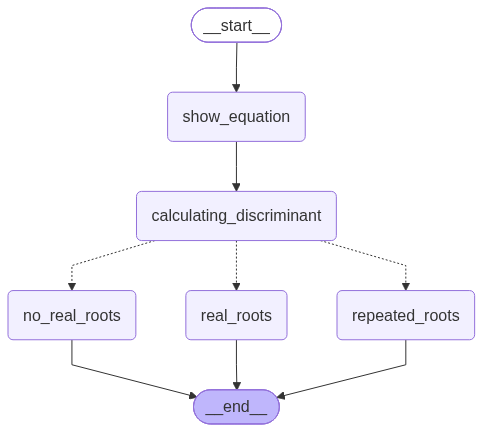

In [25]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

In [26]:
# execution
initial_state = {
    'a': 9,
    'b': -5,
    'c': -7
}

final_state = workflow.invoke(initial_state)
print(final_state)

{'a': 9, 'b': -5, 'c': -7, 'equation': '9x2-5x-7', 'discriminant': 277, 'result': 'The real_roots are 7.972222222222222 and -7.416666666666667'}
